IMPORT LIBRARY AND DATASET

In [1]:
# !pip install datasets
# !pip install dask

from datasets import load_dataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
import seaborn as sns
import dask.dataframe as dd

# load the dataset and meta_data
# mbr_data = load_dataset('recmeapp/mobilerec', data_dir='interactions')
# mbr_meta = load_dataset('recmeapp/mobilerec', data_dir='app_meta')
#
# # Save dataset to .csv file for creating pandas dataframe
# mbr_data['train'].to_csv('./mbr_data.csv')
#
# # # Convert to pandas dataframe
# mobilerec_df = pd.read_csv('./mbr_data.csv')
#
# # How many interactions are there in the MobileRec dataset?
# print(f'There are {len(mobilerec_df)} interactions in mobilerec dataset.')
#
# # How many unique app_packages (apps or items) are there?
# print(f'There are {len(mobilerec_df["app_package"].unique())} unique apps in mobilerec dataset.')
#
# # How many unique users are there in the mobilerec dataset?
# print(f'There are {len(mobilerec_df["uid"].unique())} unique users in mobilerec dataset.')
#
# # How many categoris are there?
# print(f'There are {len(mobilerec_df["app_category"].unique())} unique categories in mobilerec dataset.')



C:\Users\YUVRAJ\miniconda3\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


READ AND LOAD DATASET

In [2]:
# df = pd.read_csv('mbr_data.csv')

# Load dataset using Dask
df = dd.read_csv("mbr_data.csv")
# df.head()

TARGET_ROWS = 1_000_000
TOTAL_ROWS = len(df)

# Calculate sampling fraction
sample_frac = TARGET_ROWS / TOTAL_ROWS
print("Sampling fraction:", sample_frac)

# ---- Step 1: Get unique users ----
unique_users = df[['uid']].drop_duplicates()

# ---- Step 2: Sample users ----
sampled_users = unique_users.sample(
    frac=sample_frac,
    random_state=42
).persist()

# ---- Step 3: Filter full user histories ----
df_sample = df.merge(
    sampled_users,
    on='uid',
    how='inner'
).persist()


# ================================
# 5. VERIFY SAMPLE
# ================================
print("Sample rows:", len(df_sample))
print("Sample users:", df_sample['uid'].nunique().compute())
print("Sample apps:", df_sample['app_package'].nunique().compute())


# ================================
# 6. SAVE SAMPLE (IMPORTANT)
# ================================
df_sample.to_csv(
    "data/mobilerec_user_sample_1M_*.csv",
    index=False,
    single_file=False
)


print("✅ User-level 1M sample saved successfully")


Sampling fraction: 0.05182147563828382
Sample rows: 1006100
Sample users: 36284
Sample apps: 10054
✅ User-level 1M sample saved successfully


E.D.A
🔍 Phase 2 — EDA Plan

We will explore these key areas:

1️⃣ Dataset Structure

Total users, apps, interactions

Column meaning & data quality

Missing value check

2️⃣ User Behavior Analytics

Average number of apps per user

Daily / session usage activity

Most popular app categories

3️⃣ Engagement Features for ML

We will engineer:

Total interactions per user

Days active

Recency (last active date)

Category preference vector

Average engagement score

These features will power:
✔ Recommendation Model
✔ Churn Prediction Model

In [3]:
df_sample = dd.read_csv("data/mobilerec_user_sample_1M_*.csv")
## convert dask to pandas
df = df_sample.compute()           ## convert into dataframe format
df_raw = df.copy()
# print(type(df))
# df.shape
# df.head()
# df.tail()
# print(len(df))
# df.columns
# df.info()
# df.describe().compute()

## get dataset summmary :-
# num_users = df['uid'].nunique().compute()
# num_apps = df['app_package'].nunique().compute()
# num_interactions = len(df)
#
# num_users, num_apps, num_interactions

# df.isnull().sum().compute()

## DATA VALIDATION AND ANOMALY CHECKING
# df[(df['rating'] < 1) | (df['rating'] > 5)].shape[0].compute()
# df[df['rating'] == 0].shape[0].compute()
# df[df['unix_timestamp']<=0].shape[0].compute()
# df[df['votes']<0].shape[0].compute()

user_interactions = df.groupby('uid').size()
mean_val = user_interactions.mean()
median_val = user_interactions.median()
# summary = {
#     'total_user':df['uid'].nunique().compute(),
#     'total_apps':df['app_package'].nunique().compute(),
#     'total_interactions':len(df),
#     'avg_interaction_per_user':user_interactions.mean().compute(),
#     'median_interaction_per_user':user_interactions.quantile(0.5).compute(),
# }
# summary
# user_interactions_pd =  user_interactions.compute()


## THE DATSET CONSIST OF 19.3M INTERACTION FROM 700K USERS ACROSS 10K MOBILE APPLICATION. USER PERFORM A MEDIAN OF 8.0 INTERACTION ,WITH A HEAVY-TAILED DISTIBUTION INDICATING PRESENECE OF POWER USERS.

## VISUALIZATION STATISTICS
numeric_col = ['rating','votes','unix_timestamp']
# for i in numeric_col:
#     plt.figure(figsize=(6,4))
#     sns.histplot(data=df[i],kde=True)
#     # df[i].hist(bins=50,log=(i != 'rating'))
#     # plt.xlabel(i)
#  #    plt.ylabel('count'   )
#     plt.title(f"Distribution of {i}")
#     plt.show()


# plt.figure(figsize = (10,10))
# # user_interactions.hist(bins = 100)
# sns.histplot(user_interactions, bins = 100, kde = True)
# plt.xlabel('Number of interactions per Users')
# plt.ylabel('Number of users(log scale)')
# plt.title('User Engagement Distribution (Log Scale)')
# plt.show()

## LEFT SKEW DATA DISTRIBUTION IN USER INTERACTIONS MOST OF THE USER ENGAGE 2-5 APPS AND LESS THAN 3-5 USER ENGAGE 150-200 APPS


# plt.figure(figsize = (10,10))
# user_interactions.hist(bins = 50)
# plt.axvline(mean_val, linestyle = '--',label = 'Mean')
# plt.axvline(median_val, linestyle = '-',label = 'Median')
# plt.legend()
# plt.title('User interaction Distribution with Mean & Median')
# plt.show()
# df['app_category'].value_counts()


DATA CLEANING AND PREPROCESSING

In [4]:
## HANDLE MISSING VALUES
# df.isnull().sum()
# df.drop(columns=['review'], inplace=True)
# df.drop(columns=['date'],inplace=True)
# df.drop(columns=['formated_date'],inplace=True)

## CHECK & OPTIMIZE DATA TYPES
# df.dtypes
df['app_package'] = df['app_package'].astype('category')
df['rating'] = df['rating'].astype('int8')
df['votes'] = df['votes'].astype('int32')
df['uid'] = df['uid'].astype('category')
df['unix_timestamp'] = df['unix_timestamp'].astype('int64')
df['event_time'] = pd.to_datetime(df['unix_timestamp'], unit='s')
df['app_category'] = df['app_category'].astype('category')
# df.dtypes
# df.info(memory_usage='deep')

## HANDLE INCONSISTENT CATEGORIES
# df['votes'].describe()
q99 = np.percentile(df['votes'], 99)            ## 99% of votes
df.loc[df['votes']>q99,'votes'] = q99                ## replace q99 those row there value greater than q99
# df['votes'].describe()

# neg_votes = df[df['votes']<0]
# print(neg_votes.shape[0])

## TIMESTAMP HANDLE
# now  = pd.Timestamp.now()
# future_rows = df[df['event_time']>now]           ## future timestamp not possible
# print(future_rows.shape[0])

# old_nows = df[df['event_time']<'2010-01-01']       ## check timestamp before 2010-01-01
# print(old_nows.shape[0])                         ## before these date mobile use unrealistic

df = df[df['event_time']>='2010-01-01']               ## filter rows later 2010-01-01 date its commonly in use mobile after that date probabily

# neg_time = df[df['unix_timestamp']<0]
# print(neg_time.shape[0])

## DROP DUPLICATES ROWS FROM TABLE:
# before = df.shape[0]
# df = df.drop_duplicates(subset=['uid','app_package','unix_timestamp'],keep='first')
# after = df.shape[0]
# print(f'before = {before} and after = {after}')

## FINAL CHECK EVERYTHING CORRECT OR NOT :
# print('min timestamp',df['event_time'].min())
# print('max timestamp',df['event_time'].max())
# print('min/max votes',df['votes'].min(),df['votes'].max())

## VISUALIZE
# plt.figure(figsize=(8,4))
# plt.boxplot(df['votes'], vert=False)
# plt.title("Box Plot of Votes")
# plt.xlabel("Votes")
# plt.show()

# plt.figure(figsize=(6,4))
# plt.boxplot(df['rating'], vert=False)
# plt.title("Box Plot of Ratings")
# plt.show()

# plt.figure(figsize=(8,4))
# plt.boxplot(df['unix_timestamp'], vert=False)
# plt.title("Box Plot of Unix Timestamp")
# plt.show()

## BOXPLOT OF USER INTERACTION
user_interactions = df.groupby('uid').size()

# plt.figure(figsize=(10,4))
# plt.boxplot(user_interactions, vert=False)
# plt.title("Box Plot of User Interactions")
# plt.xlabel("Interactions per User")
# plt.show()

# log_interaction = np.log1p(user_interactions)
#
# plt.figure(figsize=(10,5))
# sns.histplot(log_interaction,bins=40, kde=True)
# plt.title("Histogram + KDE of Log-Transformed Votes")
# plt.xlabel("log(interaction + 1)")
# plt.show()









FEATURE ENGINEERING

In [5]:
## RECENCY :        how many days they active
reference_days = df['event_time'].max()
last_activity = df.groupby('uid')['event_time'].max()
recency = (reference_days-last_activity).dt.days
recency.name = 'recency_days'

## FREQUENCY & total_interaction : how many interaction each user with apps
frequency = df.groupby('uid').size()
frequency.name = 'total_interaction'

## ENGAGEMENT SPAN   : how many days they active in apps
active_days = (df.assign(event_date=df['event_time'].dt.date).groupby('uid')['event_date'].nunique())
active_days.name = 'active_days'

## USER LIFETIME : how long user uses these apps
first_activity = df.groupby('uid')['event_time'].min()
user_lifetime = (last_activity-first_activity).dt.days
user_lifetime.name = 'user_lifetime_days'


## AVERAGE RATING GIVEN BY USER : average rating gave user to apps
avg_rating = df.groupby('uid')['rating'].mean()
avg_rating.name = 'avg_rating'

## RATING VARIANCE : how much standard deviation in rating each user
rating_std = df.groupby('uid')['rating'].std().fillna(0)
rating_std.name = 'rating_std'


## CATEGORY DIVERSITY   : how many unique category of apps they engage
category_div = df.groupby('uid')['app_category'].nunique()
category_div.name = 'category_div'

## APP DIVERSITY : how many types of apps they interact
app_div = df.groupby('uid')['app_package'].nunique()
app_div.name = 'unique_app'

## COMBINE USER FEATURE : combine all features and create single user_features table
user_features = pd.concat([recency,frequency,active_days,user_lifetime,avg_rating,rating_std,category_div,app_div],axis=1).reset_index()

# user_features.head()
# user_features.columns


# OUTLIER HANDLING : we would remove outliers from below features
cap_cols = ['total_interaction', 'active_days', 'unique_app', 'category_div']

for col in cap_cols:
    q99 = user_features[col].quantile(0.99)       ## we store 99% percentile of each features
    user_features[col] = user_features[col].clip(upper=q99)       ## if any value above then 99% percentile so they remove from features

# TIME-BASED CHURN LABEL  : create churn feature based on time if any user inactive last 30days so they are churn user otherwise they are active user
churn_days = 30
last_activity = df.groupby('uid')['event_time'].max()
cutoff_date = df['event_time'].max()-pd.Timedelta(days=churn_days)

user_features['churn'] = (user_features['uid'].map(last_activity) < cutoff_date).astype(int)
user_features['churn'].value_counts(normalize=True)
user_features.head()

user_features = user_features.drop('recency_days', axis=1)      ## drop recency_days they are label leakage feature
user_features.head()







,uid,total_interaction,active_days,user_lifetime_days,avg_rating,rating_std,category_div,unique_app,churn
0,00JZ1DWvzlYrsakR,114,110,3269,3.122807,1.505978,37,111,0
1,00YdvuA4PBpo88SK,41,41,2045,3.170732,1.531379,21,41,0
2,00dLg3En4V6SUkKv,9,9,1001,2.888889,1.691482,7,9,0
3,00edxCRm0luKVYaO,7,7,1067,3.571429,1.133893,6,7,0
4,00fXFd76YryRaydg,11,10,2346,2.636364,1.206045,11,11,0


MODELING

In [6]:
## SELECT FEATURES AND TARGET
y = user_features['churn']
X = user_features.drop(columns=['churn','uid'])
# X.shape

## TRAIN-TEST SPLIT
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42,stratify=y)  # so churn ratio stays same in train/test use stratify

## FEATURE SCALING
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## LOGISTIC REGRESSION
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_scaled, y_train)

## EVALUATE LOGISTIC REGRESSION
from sklearn.metrics import classification_report,roc_auc_score

y_pred = lr.predict(X_test_scaled)
y_proba = lr.predict_proba(X_test_scaled)[:,1]

print(classification_report(y_test, y_pred))
print('ROC_AUC :',roc_auc_score(y_test, y_proba))

# CONCLUSION:
## THESE MODEL HELP TO ANALYSIS WHICH CUSTOMER ARE CHURN ACCORDING THAT MODEL AND DASHBOARD WE GIVE DISCOUNT AND OFFER TO CUSTOMER  FOR COMEBACK TO APP AND WEBSITE
## WE CONVERT 1MILLION OF DATA IN SIMPLE ~37K NAME USER_FEATURES NAME TABLE AND CREATE MODEL USING BASELINE LOGESTIC REGRESSION.
## HOW TO WORK THESE ML MODEL WE ENTER DATA THEN THEY PREDICT ITS CHURN AND WHAT PROBABILITY OF THESE PREDICATION.

              precision    recall  f1-score   support

           0       0.85      0.60      0.70      4102
           1       0.62      0.86      0.72      3155

    accuracy                           0.71      7257
   macro avg       0.73      0.73      0.71      7257
weighted avg       0.75      0.71      0.71      7257

ROC_AUC : 0.7875246970864198


RANDOM FOREST MODEL (IMPROVE MODEL)

              precision    recall  f1-score   support

           0       0.86      0.57      0.69      4102
           1       0.61      0.88      0.72      3155

    accuracy                           0.71      7257
   macro avg       0.74      0.73      0.71      7257
weighted avg       0.76      0.71      0.70      7257

ROC_AUC : 0.788100157551378
CV ROC AUC Mean: 0.7953853262322378


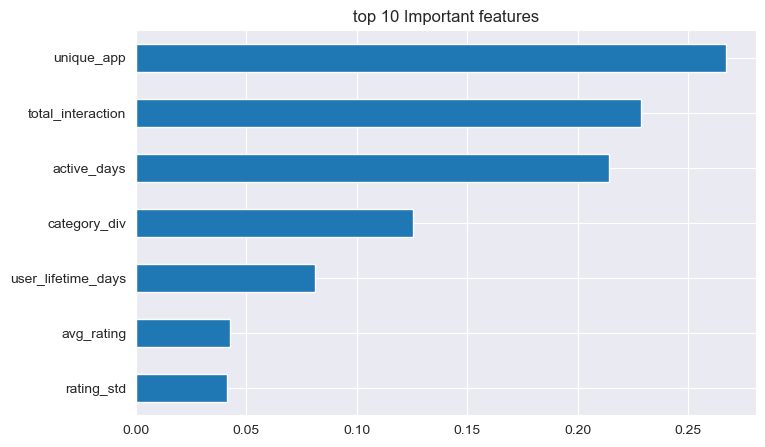

In [7]:
## RANDOM FOREST MODEL (OMPROVEMENT MODEL)
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=200,max_depth=10,random_state=42,min_samples_split=20,class_weight='balanced')       # create randomforestclassiier object

rf.fit(X_train, y_train)               # apply on train dataset


## EVALUATION :
from sklearn.metrics import classification_report,roc_auc_score

y_pred = rf.predict(X_test)
y_proba = rf.predict_proba(X_test)[:,1]

print(classification_report(y_test, y_pred))
print('ROC_AUC :',roc_auc_score(y_test, y_proba))

## CONCLUSION :
# RANDOM FOREST IS ADVANCED MODEL ALGORITHM MAKE MODEL MORE ADVANCED

## CROSS-VALIDATION
from sklearn.model_selection import cross_val_score

cv_auc = cross_val_score(
    rf, X, y, cv=5, scoring='roc_auc'
)

print("CV ROC AUC Mean:", cv_auc.mean())

## FEATURE IMPORTANCE
feature_imp = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)  # visualization of bar graph  each feature how much important in these model

plt.figure(figsize = (8,5))
feature_imp.head(10).plot(kind='barh')
plt.title('top 10 Important features')
plt.gca().invert_yaxis()
plt.show()



THRESHOLD TUNING (ADVANCED ML THINKING)

In [8]:
from sklearn.metrics import precision_recall_fscore_support

threshold = 0.4
y_custom = (y_proba > threshold).astype(int)

precision,recall,f1,_ = precision_recall_fscore_support(y_test,y_custom,average='binary')

print("precision:",precision)
print("recall:",recall)
print("f1:",f1)

precision: 0.6017121891561353
recall: 0.9356576862123613
f1: 0.7324153330852251


SAVE TRAINED MODEL AND SCALER:

In [9]:
import joblib

joblib.dump(rf,'churn_model.pkl')
joblib.dump(scaler,'scaler.pkl')

## save columns used in training
joblib.dump(list(X.columns),'feature_columns.pkl')

['feature_columns.pkl']

USER_FEATURE TABLE CONVERT INTO CSV FILE

In [10]:
user_features.to_csv("churn_user.csv",index=False)